In [1]:
from collections import Counter
def convertSeq2KmerCount(k,index_kaa,seq):
    kmers = [seq[i:i+k] for i in range(len(seq) - k + 1)]
    kmer_counts = Counter(kmers)
    kc_profile=[0]*len(index_kaa)
    for kmer,count in kmer_counts.items():
        kc_profile[index_kaa[kmer]]=count
    return kc_profile

In [2]:
aa=['A','R','N','D','C','Q','E','G','H','I','L','K','M','S','P','F','T','W','Y','V','X']
k2aa=[]
for a in aa:
    for b in aa:
        k2aa.append(a+b)
print (len(k2aa))
print (k2aa)
index_kaa={}
for i in range(len(k2aa)):
    index_kaa[k2aa[i]]=i
k3aa=[]
for a in aa:
    for b in aa:
        for c in aa:
            k3aa.append(a+b+c)
print (len(k3aa))
#print (k2aa)
index_k3aa={}
for i in range(len(k3aa)):
    index_k3aa[k3aa[i]]=i

441
['AA', 'AR', 'AN', 'AD', 'AC', 'AQ', 'AE', 'AG', 'AH', 'AI', 'AL', 'AK', 'AM', 'AS', 'AP', 'AF', 'AT', 'AW', 'AY', 'AV', 'AX', 'RA', 'RR', 'RN', 'RD', 'RC', 'RQ', 'RE', 'RG', 'RH', 'RI', 'RL', 'RK', 'RM', 'RS', 'RP', 'RF', 'RT', 'RW', 'RY', 'RV', 'RX', 'NA', 'NR', 'NN', 'ND', 'NC', 'NQ', 'NE', 'NG', 'NH', 'NI', 'NL', 'NK', 'NM', 'NS', 'NP', 'NF', 'NT', 'NW', 'NY', 'NV', 'NX', 'DA', 'DR', 'DN', 'DD', 'DC', 'DQ', 'DE', 'DG', 'DH', 'DI', 'DL', 'DK', 'DM', 'DS', 'DP', 'DF', 'DT', 'DW', 'DY', 'DV', 'DX', 'CA', 'CR', 'CN', 'CD', 'CC', 'CQ', 'CE', 'CG', 'CH', 'CI', 'CL', 'CK', 'CM', 'CS', 'CP', 'CF', 'CT', 'CW', 'CY', 'CV', 'CX', 'QA', 'QR', 'QN', 'QD', 'QC', 'QQ', 'QE', 'QG', 'QH', 'QI', 'QL', 'QK', 'QM', 'QS', 'QP', 'QF', 'QT', 'QW', 'QY', 'QV', 'QX', 'EA', 'ER', 'EN', 'ED', 'EC', 'EQ', 'EE', 'EG', 'EH', 'EI', 'EL', 'EK', 'EM', 'ES', 'EP', 'EF', 'ET', 'EW', 'EY', 'EV', 'EX', 'GA', 'GR', 'GN', 'GD', 'GC', 'GQ', 'GE', 'GG', 'GH', 'GI', 'GL', 'GK', 'GM', 'GS', 'GP', 'GF', 'GT', 'GW', 'GY',

In [3]:
from Bio.Seq import Seq
from Bio import SeqIO
index_label={}
index_label_rev={}
count=0
list_profile2k=[]
list_profile3k=[]
unque_seq_file='/media/ktht/ExtraUbuntu/amromics/panta2/panta/out/test/g_mmseq_a_diamond_c_mcl_unique3_all/unique_seqs.fasta'
with open(unque_seq_file) as handle:
    for record in SeqIO.parse(handle, "fasta"):
        index_label[record.id]=count
        index_label_rev[count]=record.id
        count=count+1
        list_profile2k.append(convertSeq2KmerCount(2,index_kaa,str(record.seq)))

In [4]:
import os
def getIdentAlignFromCell(cells):
    pident = float(cells[2]) / 100
   
    alignment_length = int(cells[3]) # * 3
    qlen = int(cells[12])# * 3 + 3
    slen = int(cells[13])# * 3 + 3
    short_seq = min(qlen, slen)
    long_seq = max(qlen, slen)
    len_diff = short_seq / long_seq
    align_short = alignment_length / short_seq
    align_long = alignment_length / long_seq
    return pident,len_diff, align_short,align_long,qlen

diamond_result =  'matching_sequences_diamond.tsv'
cmd = f'./diamond blastp -q {unque_seq_file} -d {unque_seq_file} -p 12 --evalue 1e-06 --outfmt 6 qseqid sseqid pident length mismatch gapopen qstart qend sstart send evalue bitscore qlen slen --sensitive --max-target-seqs 100 2> /dev/null 1> {diamond_result}'
#os.system(cmd)
top_match={}
t=0.5
for line in open(diamond_result, 'r'):
    cells = line.rstrip().split('\t')            

    sid=cells[0]
    tid=cells[1]
    pident,len_diff,align_short,align_long,qlen=getIdentAlignFromCell(cells)
    if pident <= t or len_diff <= t or align_short <= t or align_long <= t:
        continue
    if not sid in top_match.keys():
        top_match[sid]={}
    top_match[sid][tid]={'ident':pident,'len':qlen,'diff':len_diff}
    

In [5]:
def transform_to_l1_space(data):
    """
    Chuyển đổi vector (x1, x2, ..., xn) thành (x1, -x1, x2, -x2, ..., xn, -xn)
    để sử dụng với FAISS L2 Distance, mô phỏng Manhattan Distance.
    """
    return np.hstack([data, -data])
    

In [6]:
import faiss
import numpy as np


array_input = np.array(list_profile2k)
#dimension=len(k2aa)
#index = faiss.IndexFlatL2(dimension)  # L2 distance-based index
#index.add(array_input)


In [7]:
transformed_data = transform_to_l1_space(array_input)
index = faiss.IndexFlatL2(transformed_data.shape[1])  # Sử dụng FAISS với L2 Distance
index.add(transformed_data)  # Thêm dữ liệu vào chỉ số

In [8]:
k = 100

sum_percent=0
list_vec=[]
index_s={}
c=0
for s in top_match.keys():
    list_vec.append(list_profile2k[index_label[s]])
    index_s[c]=s
    c=c+1
    
vecs=np.array(list_vec)
vecs=transform_to_l1_space(vecs)
x=[]
y=[]
z=[]
distances, indices = index.search(vecs, k)
print(len(indices))
for i in range(len(indices)):
    for j in range(len(indices[i])):
        s1=index_s[i]
        s2=index_label_rev[indices[i][j]]
        if s1==s2:
            continue
        d=None
        ident=None
        if s1 in top_match:
            if s2 in top_match[s1]:
                if distances[i][j]  ==0:
                    z.append(top_match[s1][s2]['ident'] )
                ident=top_match[s1][s2]['ident']  
                d=float(distances[i][j])/top_match[s1][s2]['len']
                    
                        
                    #d=float(distances[i][j])
                    
        if s2 in top_match:
            if s1 in top_match[s2]:
                if distances[i][j]  ==0:
                    z.append(top_match[s2][s1]['ident'] )
                ident=top_match[s2][s1]['ident']  
                d=float(distances[i][j])/top_match[s2][s1]['len']
                    
                    
        if not ident is None:
            x.append(ident)
            y.append(d)


29590


Hệ số hồi quy (coef_): [-6.25813454]
Hằng số (intercept_): 6.341464006639735
Điểm số R^2: 0.8462054126555392
R^2: 0.85
RMSE: 0.36


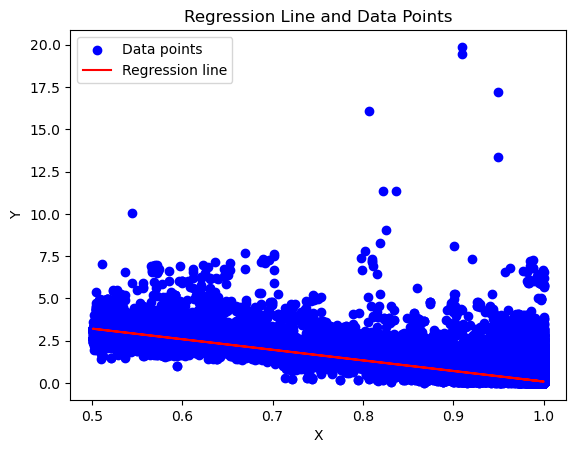

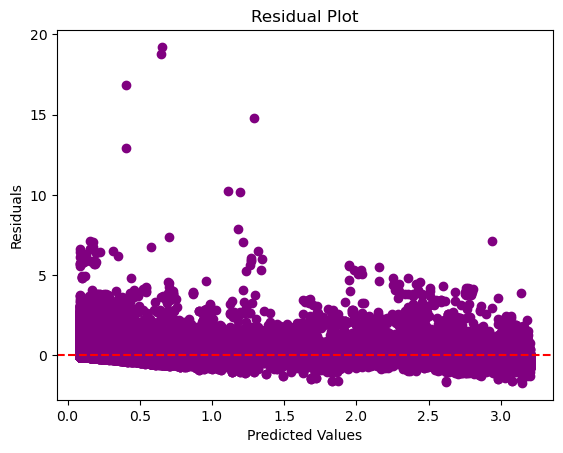

In [9]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
x=np.array(x).reshape(-1, 1)
y=np.array(y)
model = LinearRegression()
model.fit(x, y)
print("Hệ số hồi quy (coef_):", model.coef_)
print("Hằng số (intercept_):", model.intercept_)
print("Điểm số R^2:", model.score(x, y))
y_pred = model.predict(x)
# Calculate residuals
residuals = y - y_pred

# Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R^2: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

# Plot data and regression line
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label='Regression line')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Line and Data Points")
plt.legend()
plt.show()

# Plot residuals
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

29608
29608
29590
Hệ số hồi quy (coef_): [-12979.40281955]
Hằng số (intercept_): 23187.8987375896
Điểm số R^2: 0.017083270584954957
R^2: 0.02
RMSE: 13265.03


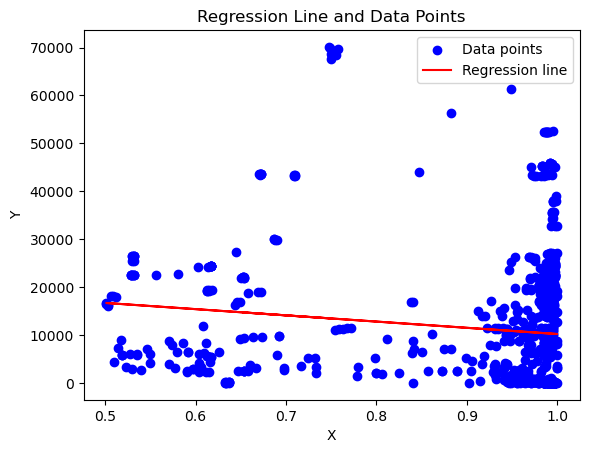

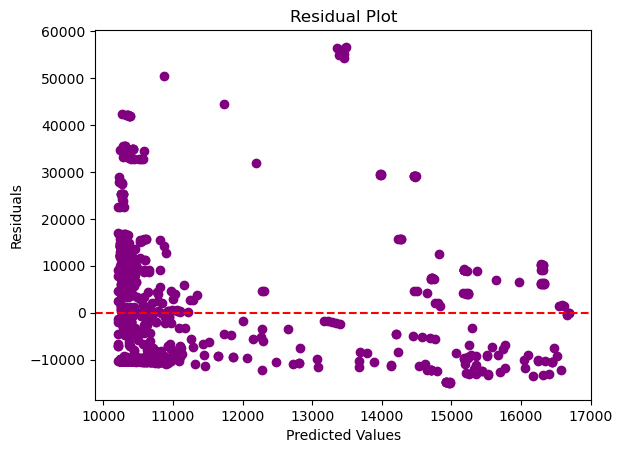

In [10]:
import torch
import esm
model, alphabet = esm.pretrained.esm2_t33_650M_UR50D()
batch_converter = alphabet.get_batch_converter()
model.eval()  # disables dropout for deterministic results
data=[]
index_label={}
index_label_rev={}
count=0
list_profile2k=[]
with open(unque_seq_file) as handle:
    for record in SeqIO.parse(handle, "fasta"):
        index_label[record.id]=count
        index_label_rev[count]=record.id
        count=count+1
        data.append((record.id,str(record.seq)))

print(len(data))
map_labels={}
batch_labels, batch_strs, batch_tokens = batch_converter(data)
print(batch_tokens.shape[0])
for i in range(len(batch_tokens)):
    map_labels[batch_labels[i]]=batch_tokens[i]
list_vec=[]
index_s={}
c=0
for s in top_match.keys():
    list_vec.append(map_labels[s].numpy())
    index_s[c]=s
    c=c+1
vecs=np.array(list_vec)
index = faiss.IndexFlatL2(vecs.shape[1])  # Sử dụng FAISS với L2 Distance
index.add(vecs)
x=[]
y=[]
z=[]
distances, indices = index.search(vecs, 100)
print(len(indices))
for i in range(len(indices)):
    for j in range(len(indices[i])):
        s1=index_s[i]
        s2=index_label_rev[indices[i][j]]
        if s1==s2:
            continue
        d=None
        ident=None
        if s1 in top_match:
            if s2 in top_match[s1]:
                if distances[i][j]  ==0:
                    z.append(top_match[s1][s2]['ident'] )
                ident=top_match[s1][s2]['ident']  
                d=float(distances[i][j])
                    
                        
                    #d=float(distances[i][j])
                    
        if s2 in top_match:
            if s1 in top_match[s2]:
                if distances[i][j]  ==0:
                    z.append(top_match[s2][s1]['ident'] )
                ident=top_match[s2][s1]['ident']  
                d=float(distances[i][j])
                    
                    
        if not ident is None:
            x.append(ident)
            y.append(d)
x=np.array(x).reshape(-1, 1)
y=np.array(y)
model = LinearRegression()
model.fit(x, y)
print("Hệ số hồi quy (coef_):", model.coef_)
print("Hằng số (intercept_):", model.intercept_)
print("Điểm số R^2:", model.score(x, y))
y_pred = model.predict(x)
# Calculate residuals
residuals = y - y_pred

# Metrics
r2 = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"R^2: {r2:.2f}")
print(f"RMSE: {rmse:.2f}")

# Plot data and regression line
plt.scatter(x, y, color='blue', label='Data points')
plt.plot(x, y_pred, color='red', label='Regression line')
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Regression Line and Data Points")
plt.legend()
plt.show()

# Plot residuals
plt.scatter(y_pred, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [11]:
data = np.array(z)
# Dữ liệu mẫu


# Tính giá trị trung bình
mean_value = 0

# Tính độ lệch trung bình tuyệt đối (MAD)
mad = np.mean(np.abs(data - mean_value))

# Tính phương sai (Variance)
variance = np.mean((data - mean_value) ** 2)

# Tính độ lệch chuẩn (Standard Deviation)
std_dev = np.sqrt(variance)

# Hiển thị kết quả
print(f"Giá trị trung bình: {mean_value:.2f}")
print(f"Độ lệch trung bình tuyệt đối (MAD): {mad:.2f}")
print(f"Phương sai (Variance): {variance:.2f}")
print(f"Độ lệch chuẩn (Standard Deviation): {std_dev:.2f}")

Giá trị trung bình: 0.00
Độ lệch trung bình tuyệt đối (MAD): 0.86
Phương sai (Variance): 0.76
Độ lệch chuẩn (Standard Deviation): 0.87
